# World Cup 2026: rebuilding a flawed expected-goals chart

A debate I kept circling back to while rebuilding this chart was really a question of what a graph claims to show versus what it measures underneath, which I found compelling in the same way the LBJ and Biden approval graphs were, where the surface reading and the real story pull apart once you look closer.

The chart I started with came from footballytics, plotting World Cup 2026 attackers along a blended vertical axis of 0.3 times goals plus 0.7 times xG per 90, and I thought the underlying concept worked well enough, since two axes sort scorers from creators and per-90 rates let you compare players across uneven minutes, though the execution had three problems I found serious enough to rebuild the whole thing around.

**The first problem was the vertical axis**, which the chart labeled as finishing quality even though the formula underneath measured shot volume and chance quality instead, and I thought this was the most misleading part, because a high-volume shooter posts a big number on that axis whether or not he finishes, so the metric buries the exact signal it claims to show. Genuine finishing shows up as goals minus xG, the overperformance a player generates beyond his chances, so I moved the vertical axis to goals per 90 minus xG per 90.

**The second problem was creation.** Once the finishing axis is fixed, I still needed the second dimension the original was reaching for, and I settled on xA per 90 because xA credits the quality of the chance a player builds, valuing a cutback into an open six-yard box far higher than a hopeful cross, whereas raw assists punish a creator whose teammates fail to finish, so xA isolates the creation a player controls from the conversion he does not.

**The third problem was sample size, which I thought was the worst of the three**, because a World Cup gives each player only a handful of games and per-90 rates off small minutes swing wildly, yet the original chart weighted a cameo substitute the same as a player who started every match, so someone like Deniz Undav topped early cuts of the data on rates drawn from under a hundred minutes. I set a floor of 270 minutes, around three full matches, and I sized every dot by minutes played, so a small sample shows up as a small dot you learn to read with more caution.

I also stripped out the quadrant labels the original leaned on, the ones sorting players into finishers, creators, and wasteful, because they bake a verdict into a five-game sample. The clearest example of the damage is Olise and Wirtz, both of whom land low on finishing in a way that reads as a flaw until you notice they carry tiny personal shot volumes and generate their value on the creation axis instead, with club records that show elite output over full seasons.

The section at the end quantifies the limit that survives every fix: even 500 World Cup minutes comes down to five or six games, so finishing measured over that few shots stays noisy. I put a confidence band on goals minus xG to show exactly how noisy.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Compiled from FotMob World Cup 2026 player stats.
# goals/90, xG/90, minutes from the finishing leaderboard (>=270 min).
# xA/90 from the chance-creation axis.
df = pd.read_csv("wc2026_attackers.csv")
df["finishing_p90"] = df["goals_p90"] - df["xg_p90"]   # overperformance = true finishing signal
df.sort_values("finishing_p90", ascending=False).head()

,name,goals_p90,xg_p90,minutes,xa_p90,finishing_p90
0,Dembele,0.97,0.30,462,0.29,0.67
1,Haaland,1.75,1.08,465,0.06,0.67
2,Messi,1.76,1.10,530,0.57,0.66
3,Kane,1.22,0.70,563,0.16,0.52
4,Quinones,0.87,0.35,414,0.09,0.52


## Chart 1: finishing versus creation, minutes-weighted

Vertical axis is finishing (goals minus xG per 90). Horizontal is creation (xA per 90). Every dot is a player past the 270-minute floor, sized by minutes. There are no quadrant lines and no labels sorting players into good or bad. Where a player sits is the information.

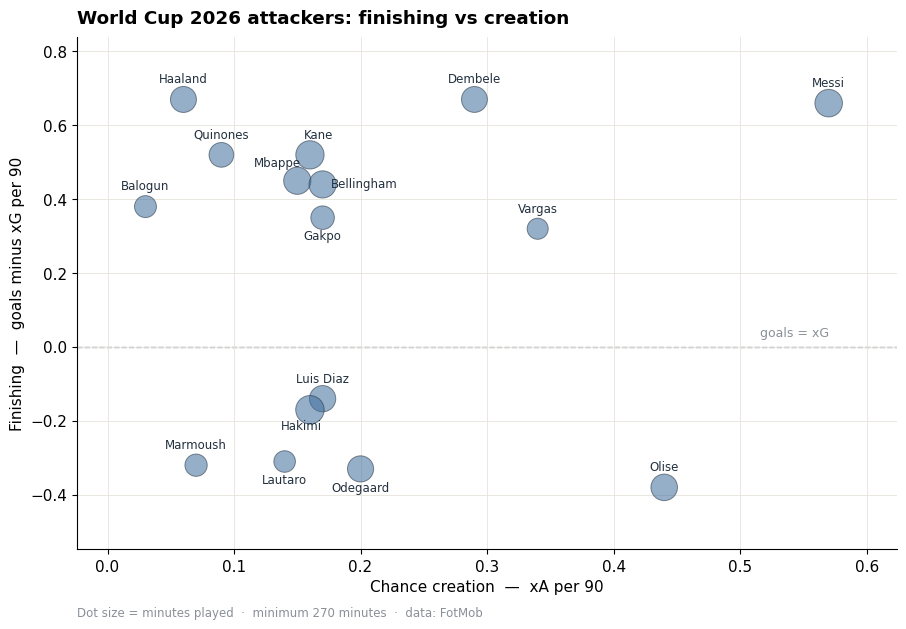

In [2]:
INK, ACCENT, MUTED, GRID = "#22303f", "#3f6d9c", "#8a8f98", "#e6e3db"
plt.rcParams.update({"font.size":11, "figure.facecolor":"white", "axes.facecolor":"white"})

off = {"Mbappe":(-14,10),"Bellingham":(30,-2),"Gakpo":(0,-16),"Kane":(6,12),"Hakimi":(-6,-14),
       "Lautaro":(0,-16),"Odegaard":(0,-16)}
fig, ax = plt.subplots(figsize=(9.2,6.4))
sizes = (df["minutes"]/df["minutes"].max()*380)+40
ax.scatter(df["xa_p90"], df["finishing_p90"], s=sizes, color=ACCENT, alpha=0.55,
           edgecolor=INK, linewidth=0.7, zorder=3)
ax.axhline(0, color=MUTED, lw=1, ls="--", zorder=1)
ax.text(df["xa_p90"].max(), 0.02, "goals = xG", color=MUTED, fontsize=9, ha="right", va="bottom")
for _, r in df.iterrows():
    dx, dy = off.get(r["name"], (0,12))
    ax.annotate(r["name"], (r["xa_p90"], r["finishing_p90"]), xytext=(dx,dy),
                textcoords="offset points", ha="center", fontsize=8.5, color=INK)
ax.set_xlabel("Chance creation  —  xA per 90")
ax.set_ylabel("Finishing  —  goals minus xG per 90")
ax.set_title("World Cup 2026 attackers: finishing vs creation", fontweight="bold", loc="left", pad=10)
ax.grid(color=GRID, lw=0.6, zorder=0); ax.margins(x=0.10, y=0.16)
ax.text(0.0,-0.13,"Dot size = minutes played  ·  minimum 270 minutes  ·  data: FotMob",
        transform=ax.transAxes, fontsize=8.5, color=MUTED)
for s in ["top","right"]: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

How to read it without the crutch of labels. Up and to the right means both scoring above expectation and creating: Messi sits alone out there, off 530 minutes, so his creation number is earned rather than a small-sample fluke. Straight up with little rightward drift is a scorer who does not create, like Haaland. Far right and low is a creator whose own shots are secondary, like Olise. A player sitting below the line is not a poor finisher, he has scored fewer than his chances predicted over a tiny sample, which is a different claim.

But before trusting any vertical position, look at how noisy that finishing axis really is.

## The statistics: how much can you trust tournament finishing?

Goals is a sum of Bernoulli trials, one per shot, where each shot converts with probability equal to its xG. Treating a player's total xG as the fixed expectation, the variance of his goal count is close to that total xG, so the standard deviation of goals minus xG is about the square root of total xG. Converting that spread to a per-90 rate gives a confidence band on the finishing number.

The key point: total xG over a World Cup is small (Messi's is about 6.5), so the square-root term is large relative to the signal. Finishing per 90 gets a wide band. Over a full club season the same rate accumulates a much larger total xG, and the band tightens.

In [3]:
df["total_xg"] = df["xg_p90"] * df["minutes"]/90.0          # expected goals over the tournament
df["sd_finishing_p90"] = np.sqrt(df["total_xg"]) / (df["minutes"]/90.0)
df["ci95_p90"] = 1.96 * df["sd_finishing_p90"]

crosses = ((df["finishing_p90"] - df["ci95_p90"] < 0) &
           (df["finishing_p90"] + df["ci95_p90"] > 0)).sum()
print(f"{crosses} of {len(df)} players have a 95% finishing band that crosses zero.")
df.sort_values("finishing_p90", ascending=False)[
    ["name","finishing_p90","minutes","total_xg","ci95_p90"]
].round(2)

15 of 16 players have a 95% finishing band that crosses zero.


,name,finishing_p90,minutes,total_xg,ci95_p90
0,Dembele,0.67,462,1.54,0.47
1,Haaland,0.67,465,5.58,0.90
2,Messi,0.66,530,6.48,0.85
3,Kane,0.52,563,4.38,0.66
4,Quinones,0.52,414,1.61,0.54
5,Mbappe,0.45,518,5.41,0.79
6,Bellingham,0.44,515,2.58,0.55
7,Balogun,0.38,314,1.67,0.73
8,Gakpo,0.35,371,1.57,0.60
9,Vargas,0.32,285,1.01,0.62


Fifteen of sixteen players have a 95% band that crosses zero. At World Cup sample sizes, almost no one's finishing is statistically distinguishable from average. The chart below shows why.

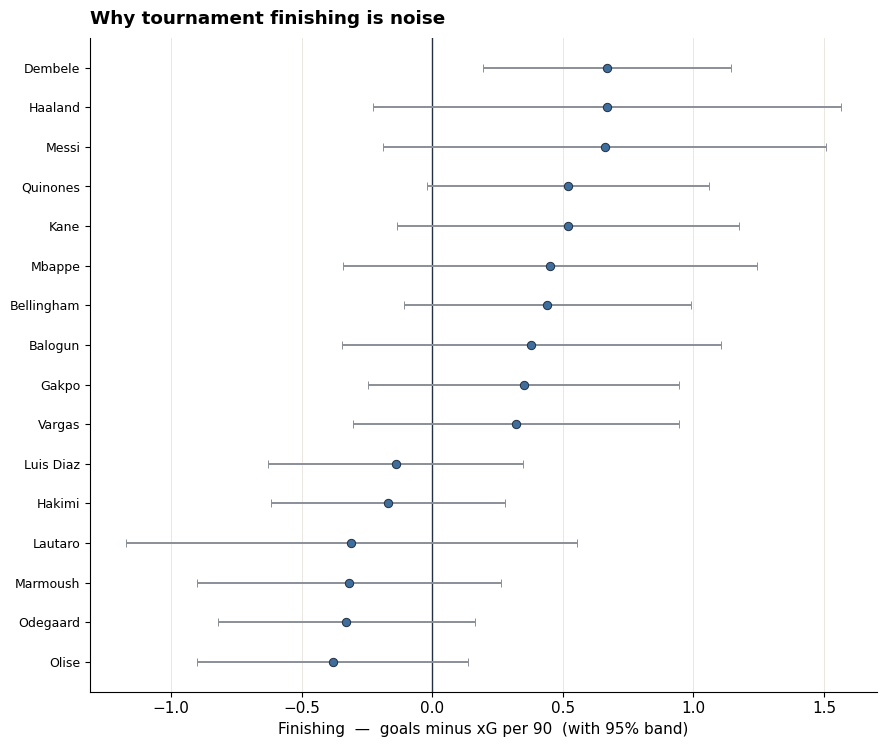

In [4]:
d2 = df.sort_values("finishing_p90")
fig, ax = plt.subplots(figsize=(9,7.6))
y = np.arange(len(d2))
ax.errorbar(d2["finishing_p90"], y, xerr=d2["ci95_p90"], fmt="o", color=ACCENT,
            ecolor=MUTED, elinewidth=1.4, capsize=3, markersize=6,
            markeredgecolor=INK, markeredgewidth=0.7, zorder=3)
ax.axvline(0, color=INK, lw=1, zorder=2)
ax.set_yticks(y); ax.set_yticklabels(d2["name"], fontsize=9)
ax.set_xlabel("Finishing  —  goals minus xG per 90  (with 95% band)")
ax.grid(axis="x", color=GRID, lw=0.6, zorder=0)
for s in ["top","right"]: ax.spines[s].set_visible(False)
ax.set_title("Why tournament finishing is noise", fontweight="bold", loc="left", pad=10)
plt.tight_layout(); plt.show()

A minutes floor removes the substitute bias, it does not manufacture a larger sample. The last chart shows the confidence band shrinking as minutes grow, with the World Cup range shaded. Even at the top of that range, the band is roughly twice as wide as it becomes over a full season.

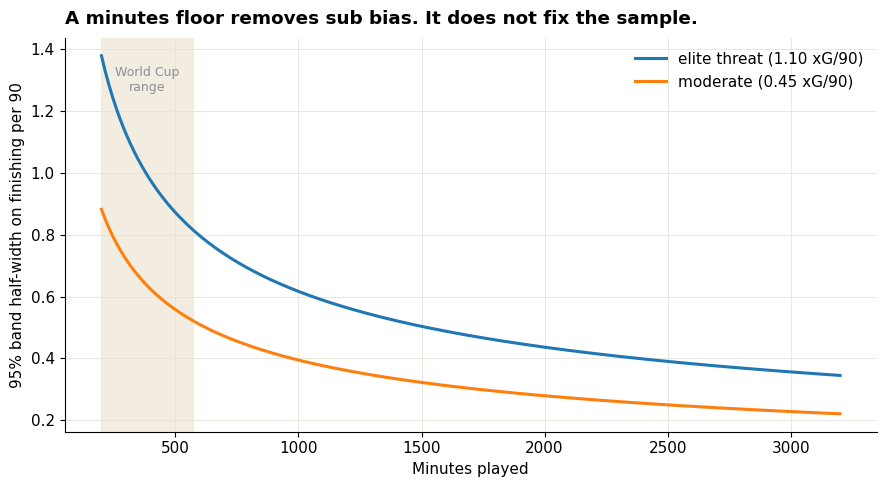

In [5]:
fig, ax = plt.subplots(figsize=(9,5))
mins = np.linspace(200, 3200, 200)
for xg, label in [(1.10,"elite threat (1.10 xG/90)"), (0.45,"moderate (0.45 xG/90)")]:
    total = xg*mins/90.0
    ci = 1.96*np.sqrt(total)/(mins/90.0)
    ax.plot(mins, ci, lw=2.2, label=label)
ax.axvspan(200, 570, color="#f3ede1", zorder=0)
ax.text(385, ax.get_ylim()[1]*0.88, "World Cup\nrange", ha="center", fontsize=9, color=MUTED)
ax.set_xlabel("Minutes played")
ax.set_ylabel("95% band half-width on finishing per 90")
ax.set_title("A minutes floor removes sub bias. It does not fix the sample.", fontweight="bold", loc="left", pad=10)
ax.legend(frameon=False); ax.grid(color=GRID, lw=0.6, zorder=0)
for s in ["top","right"]: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

## What I take from this

The rebuilt chart fixes the original's three flaws: a finishing axis that measures finishing, a creation axis that isolates creation, and a minutes floor with sized dots that stops cameo samples from distorting the picture. The takeaway I landed on across the whole build is that you should read a player's position as a lean rather than a verdict, and the confidence bands put a number on how soft that lean is.

The method matters more than the football. Take a metric, work out what it actually measures, model the noise instead of trusting the point estimate, and read the distribution rather than the single number. The same discipline applies to any noisy performance signal, including a trading strategy judged on a short track record.

**Data note.** Figures were compiled from FotMob's World Cup 2026 player stats during analysis. The finishing model treats each player's total xG as a fixed expectation and goals as the random outcome, which is a standard first-order approximation, not a full hierarchical model.